In [1]:
import sys
import os

from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# --- IGNORE ---
sys.path.append(os.path.abspath(".."))

base_path = Path.cwd()
parent_path = base_path.parent
train_path = parent_path / 'data' / 'raw' / 'train.csv'
test_path = parent_path / 'data' / 'raw' / 'test.csv'

In [3]:
from src.features import preprocess_trip_data, convert_to_datetime, extract_datetime_features, create_rush_hour_feature, calculate_manhattan_distance, calculate_haversine_distance
from src.train import train_model
from src.models import get_random_forest_model, get_xgboost_model, get_gbr_model, get_lgbm_model, get_catboost_model
from src.predictor import predictor

In [4]:
# Load data
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


### Exploratory Data Analysis

In [5]:
# Train data information
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
# Train data exploration
print("Train data shape:", train_data.shape)
train_data.head()

Train data shape: (1458644, 11)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [7]:
print("Missing values in train data: {}".format(train_data.isnull().sum().sum()))
print("Duplicated rows in train data: {}".format(train_data.duplicated().sum()))
print("Duplicated IDs in train data: {}".format(train_data["id"].duplicated().sum()))

Missing values in train data: 0
Duplicated rows in train data: 0
Duplicated IDs in train data: 0


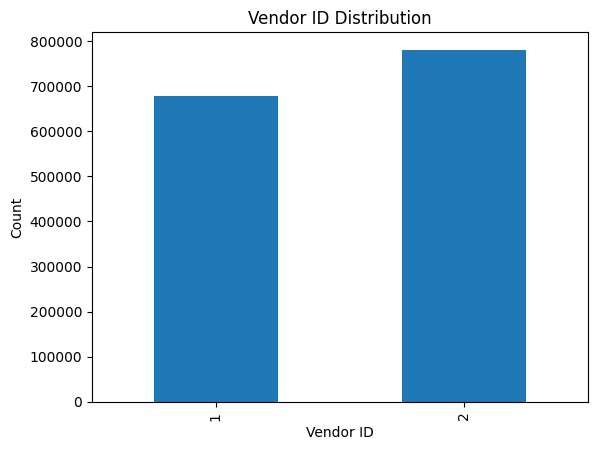

In [8]:
# Vendor ID Distribution
train_data["vendor_id"].value_counts().sort_values().plot(kind='bar')
plt.title("Vendor ID Distribution")
plt.xlabel("Vendor ID")
plt.ylabel("Count")
plt.show()

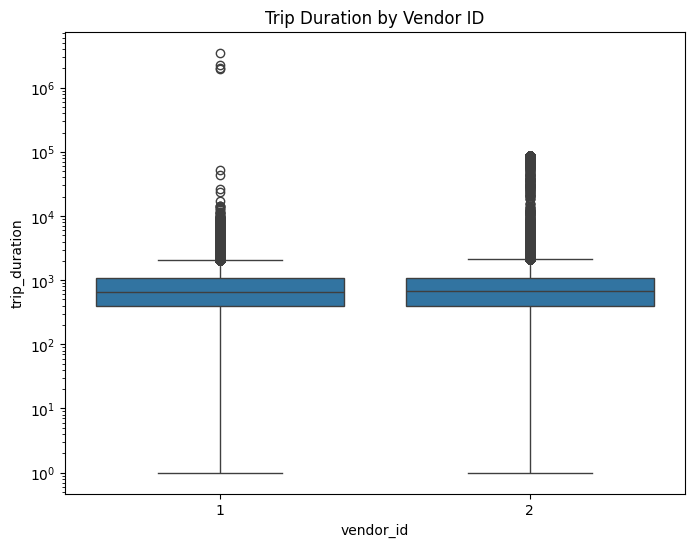

In [9]:
# Trip Duration Distribution by Vendor ID
plt.figure(figsize=(8, 6))

# Using log of trip_duration because it's usually heavily skewed
sns.boxplot(x='vendor_id', y='trip_duration', data=train_data)
plt.yscale('log') # Use log scale to handle outliers
plt.title('Trip Duration by Vendor ID')
plt.show()

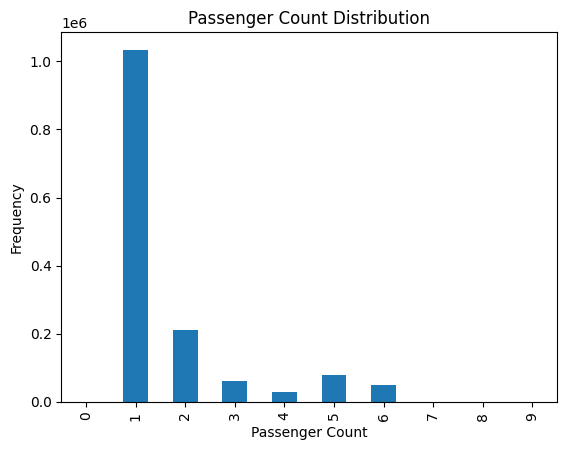

In [10]:
# Passenger Count Distribution
train_data["passenger_count"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Frequency")
plt.show()

In [11]:
train_data["passenger_count"].value_counts().sort_index()

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64

Zero passengers might indicate a canceled trip or a data entry error.

In [12]:
# Target variable exploration (outliers)
train_data["trip_duration"].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

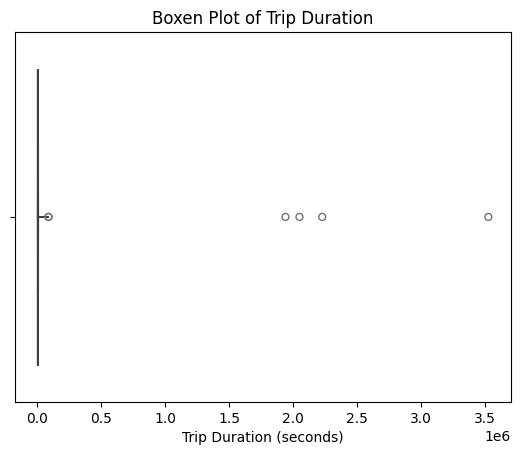

In [13]:
# Boxen plot of the target variable
sns.boxenplot(x=train_data["trip_duration"])
plt.title("Boxen Plot of Trip Duration")
plt.xlabel("Trip Duration (seconds)")
plt.show()

Dataset is extremely "bottom-heavy." With a median (50th percentile) of 662 but a maximum of 3,526,282.

The Floor: A taxi ride of 1 (unit) is likely a technical error or an immediate cancellation.

The Ceiling: A value of 3.5 million (40 days) is almost certainly a meter left running or a GPS glitch.

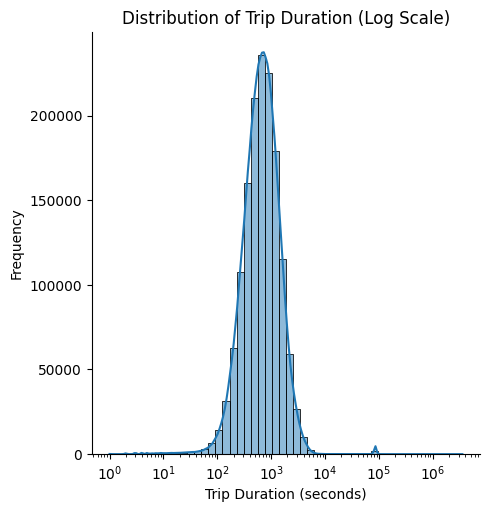

In [14]:
#Log-scale histogram of the target variable
sns.displot(train_data["trip_duration"], kind="hist", bins=50, log_scale=True, kde=True)
plt.title("Distribution of Trip Duration (Log Scale)")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

### Feature engineering

In [15]:
# Remove outliers based on trip duration (e.g., trips longer than 2 hours or shorter than 1 minute) and remove rows with zero passengers
train_data_clean = preprocess_trip_data(train_data)
print("Train data after cleaning rows", train_data_clean.shape)

Train data after cleaning rows (1447597, 11)


In [16]:
# Convert pickup_datetime to datetime, extract features, and create rush hour feature
train_data_clean = convert_to_datetime(train_data_clean)
train_data_clean = extract_datetime_features(train_data_clean)
train_data_clean = create_rush_hour_feature(train_data_clean)

train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0


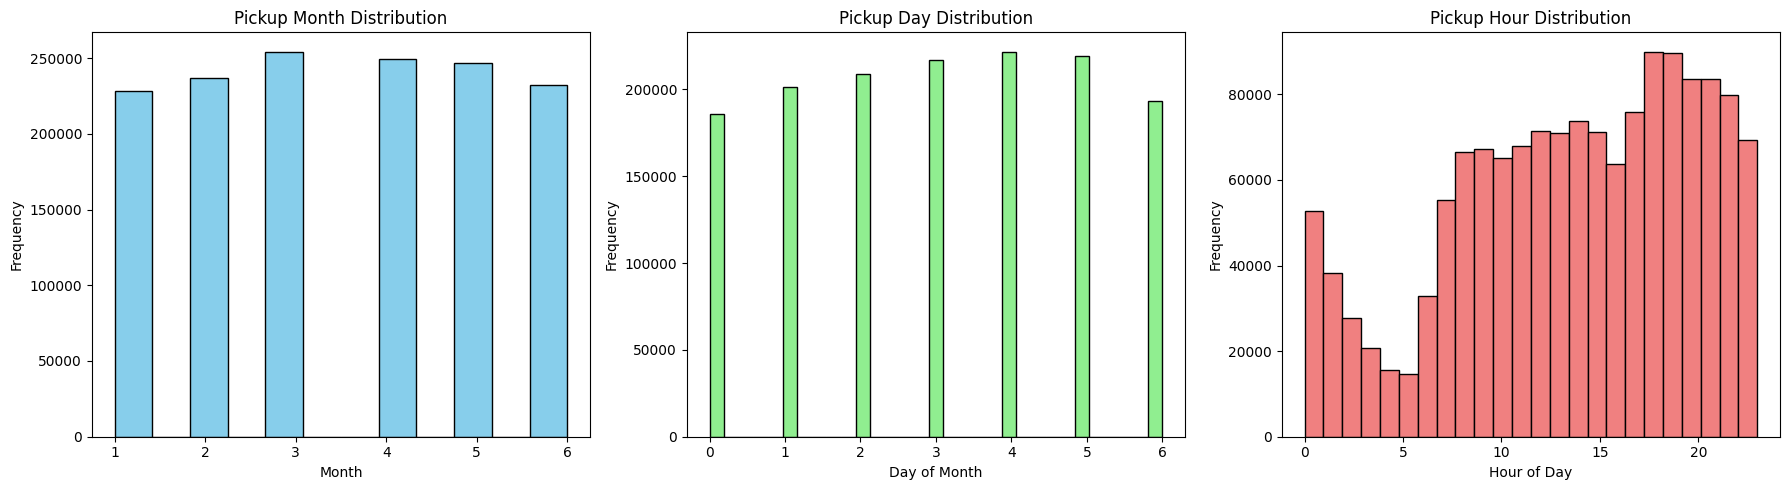

In [17]:
# Visualize the distribution of pickup month, day, and hour
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(train_data_clean["pickup_month"], bins=12, color='skyblue', edgecolor='black')
axes[0].set_title("Pickup Month Distribution")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Frequency")

axes[1].hist(train_data_clean["pickup_day"], bins=31, color='lightgreen', edgecolor='black')
axes[1].set_title("Pickup Day Distribution")
axes[1].set_xlabel("Day of Month")
axes[1].set_ylabel("Frequency")

axes[2].hist(train_data_clean["pickup_hour"], bins=24, color='lightcoral', edgecolor='black')
axes[2].set_title("Pickup Hour Distribution")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [18]:
# Createte distance features using the Manhattan and Haversine distance functions
train_data_clean["manhattan_distance"] = calculate_manhattan_distance(train_data_clean["pickup_latitude"], train_data_clean["pickup_longitude"],
                                     train_data_clean["dropoff_latitude"], train_data_clean["dropoff_longitude"])

train_data_clean["haversine_distance"] = calculate_haversine_distance(train_data_clean["pickup_latitude"], train_data_clean["pickup_longitude"],
                                     train_data_clean["dropoff_latitude"], train_data_clean["dropoff_longitude"])

In [19]:
train_data_clean.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,rush_hour,manhattan_distance,haversine_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,1,0.019859,0.026154
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,0,0.026478,0.031512
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,0.080158,0.111441
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,1,0.015480,0.025927
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,0,0.010818,0.020745


### Feature Sets

In [20]:
# Prepare the data for modeling
BASE_FEATURES = ["vendor_id", "pickup_hour", "pickup_day", "pickup_month", "passenger_count", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]

ENGINEERED_FEATURES = BASE_FEATURES + ["manhattan_distance", "haversine_distance", "rush_hour"]

### Track results

In [21]:
# Train models and evaluate performance
best_result = []
best_score = float('inf')

results = []

experiments = [
    {"name": "RF_base", "model": get_random_forest_model(), "features": BASE_FEATURES},
    {"name": "XGB_base", "model": get_xgboost_model(), "features": BASE_FEATURES},
    {"name": "GBR_base", "model": get_gbr_model(), "features": BASE_FEATURES},
    {"name": "LGBM_base", "model": get_lgbm_model(), "features": BASE_FEATURES},
    {"name": "Cat_base", "model": get_catboost_model(), "features": BASE_FEATURES},
    {"name": "Cat_engineered", "model": get_catboost_model(), "features": ENGINEERED_FEATURES},
    {"name": "XGB_engineered", "model": get_xgboost_model(), "features": ENGINEERED_FEATURES},
    {"name": "GBR_engineered", "model": get_gbr_model(), "features": ENGINEERED_FEATURES},
    {"name": "LGBM_engineered", "model": get_lgbm_model(), "features": ENGINEERED_FEATURES},
    {"name": "RF_engineered", "model": get_random_forest_model(), "features": ENGINEERED_FEATURES}
]

for exp in experiments:
    score = train_model(exp["model"], exp["features"], train_data_clean)

    results.append({
        "name": exp["name"],
        "model": exp["model"],
        "features": exp["features"],
        "score": score
    })

    if score < best_score:
        best_score = score
        best_result = exp

    print(f"Experiment: {exp['name']}, Features: {exp['features']}, RMSLE: {score:.4f}")

Experiment: RF_base, Features: ['vendor_id', 'pickup_hour', 'pickup_day', 'pickup_month', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], RMSLE: 0.0701
Experiment: XGB_base, Features: ['vendor_id', 'pickup_hour', 'pickup_day', 'pickup_month', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], RMSLE: 0.0485
Experiment: GBR_base, Features: ['vendor_id', 'pickup_hour', 'pickup_day', 'pickup_month', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], RMSLE: 0.0486
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1068
[LightGBM] [Info] Number of data points in the train set: 1158077, number of used features: 9
[LightGBM] [Info] Start training

In [22]:
best_result["model"]

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

### Compare results

In [23]:
results_df = pd.DataFrame(results).sort_values("score")
results_df

,name,model,features,score
6,XGB_engineered,"XGBRegressor(base_score=None, booster=None, ca...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.045749
7,GBR_engineered,([DecisionTreeRegressor(criterion='friedman_ms...,"[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.045789
1,XGB_base,"XGBRegressor(base_score=None, booster=None, ca...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.048479
5,Cat_engineered,"CatBoostRegressor(learning_rate=0.1, loss_func...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.048498
2,GBR_base,([DecisionTreeRegressor(criterion='friedman_ms...,"[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.048625
8,LGBM_engineered,"LGBMRegressor(max_depth=10, random_state=42)","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.048999
9,RF_engineered,"(DecisionTreeRegressor(max_depth=10, max_featu...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.052283
4,Cat_base,"CatBoostRegressor(learning_rate=0.1, loss_func...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.053268
3,LGBM_base,"LGBMRegressor(max_depth=10, random_state=42)","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.056816
0,RF_base,"(DecisionTreeRegressor(max_depth=10, max_featu...","[vendor_id, pickup_hour, pickup_day, pickup_mo...",0.070132


In [24]:
results_df["model"][:1]

6    XGBRegressor(base_score=None, booster=None, ca...
Name: model, dtype: object

In [25]:
# Predict on test set
model = best_result["model"]
features = BASE_FEATURES

test_data_clean = convert_to_datetime(test_data)
test_data_clean = extract_datetime_features(test_data_clean)

Y_pred_test = predictor(model, train_data_clean, test_data_clean, features)
print("Five predictions:", Y_pred_test[:5])

Five predictions: [ 794.5872   578.0541   435.72586 1049.8434   337.23148]
